In [1]:
from torch import optim
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch
import random
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import albumentations as Albu
import pandas as pd
from torch.utils.data import DataLoader
from torch.utils.data.sampler import RandomSampler
from warmup_scheduler import GradualWarmupScheduler
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, recall_score, precision_score
from tqdm import tqdm
import os
from utils.dataset import PatchBagDataset
from utils.models import AttentionMIL

## Configuration

In [2]:
# Training parameters
seed = 42
batch_size = 2
num_workers = 4
output_classes = 5  # For ordinal encoding: ISUP 0-5 → 5 thresholds
init_lr = 3e-4
warmup_factor = 2
warmup_epochs = 1
n_epochs = 50
dropout_rate = 0.6
patience = 7

# Focal loss parameters
focal_alpha = 0.25  # Weighting factor for focal loss
focal_gamma = 2.0   # Focusing parameter (higher = more focus on hard examples)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set seeds
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Paths
ROOT_DIR = '../../..'
data_dir = '../../../..'
images_dir = os.path.join(data_dir, 'tiles')

# Output paths
os.makedirs('../logs', exist_ok=True)
os.makedirs('../models', exist_ok=True)
model_path = 'models/b0-entropy-ordinal-focal-attention.pth'
log_path = 'logs/b0-entropy-ordinal-focal-attention.txt'

Using device: cuda


In [3]:
class OrdinalFocalLoss(nn.Module):
    """
    Combined Ordinal + Focal Loss for ordered categories with class imbalance.
    
    Combines ordinal regression (respecting order) with focal loss (handling
    class imbalance and focusing on hard examples).
    
    For each sample with grade k, we create k binary labels:
    - ISUP 0: [0, 0, 0, 0, 0]
    - ISUP 1: [1, 0, 0, 0, 0]
    - ISUP 2: [1, 1, 0, 0, 0]
    - ISUP 3: [1, 1, 1, 0, 0]
    - ISUP 4: [1, 1, 1, 1, 0]
    - ISUP 5: [1, 1, 1, 1, 1]
    
    Then apply focal loss weighting:
    FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(OrdinalFocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, logits, targets):
        """
        Args:
            logits: (batch_size, num_classes) - raw outputs from model
            targets: (batch_size, num_classes) - ordinal encoded targets
        """
        # Apply sigmoid to get probabilities
        probs = torch.sigmoid(logits)
        
        # Calculate binary cross entropy (without reduction)
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        
        # Calculate p_t: probability of correct class
        # For target=1, p_t=p; for target=0, p_t=1-p
        p_t = probs * targets + (1 - probs) * (1 - targets)
        
        # Calculate focal weight: (1 - p_t)^gamma
        # This down-weights easy examples (high p_t) and focuses on hard examples (low p_t)
        focal_weight = (1 - p_t) ** self.gamma
        
        # Apply focal loss formula
        focal_loss = self.alpha * focal_weight * bce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

def encode_ordinal_labels(labels, num_classes=5):
    """
    Convert categorical labels to ordinal encoding.
    
    Args:
        labels: Tensor or array of ISUP grades (0-5)
        num_classes: Number of thresholds (5 for ISUP 0-5)
    
    Returns:
        Ordinal encoded labels: (batch_size, num_classes)
    """
    if isinstance(labels, torch.Tensor):
        labels = labels.cpu().numpy()
    
    batch_size = len(labels)
    ordinal = torch.zeros((batch_size, num_classes), dtype=torch.float32)
    
    for i, label in enumerate(labels):
        label = int(label)
        if label > 0:
            ordinal[i, :label] = 1
    
    return ordinal

def decode_ordinal_predictions(logits):
    """
    Convert ordinal predictions back to class labels.
    
    Args:
        logits: (batch_size, num_classes) - raw model outputs
    
    Returns:
        Predicted ISUP grades (0-5)
    """
    probs = torch.sigmoid(logits)
    predictions = (probs > 0.5).sum(dim=1)
    return predictions

# Initialize loss function
loss_function = OrdinalFocalLoss(alpha=focal_alpha, gamma=focal_gamma)
print(f"Ordinal + Focal Loss initialized")
print(f"  Alpha: {focal_alpha}")
print(f"  Gamma: {focal_gamma}")

Ordinal + Focal Loss initialized
  Alpha: 0.25
  Gamma: 2.0


## Load Data with Entropy Filtering

In [4]:
# Load original training data
df_train_ = pd.read_csv(f"{ROOT_DIR}/data/train_5fold.csv")
print(f"Original records: {len(df_train_)}")

# Load entropy filtered samples
df_entropy = pd.read_csv(f"{ROOT_DIR}/data/entropy.csv")
print(f"High-entropy samples to remove: {len(df_entropy)}")

df_entropy_sorted = df_entropy.sort_values(by='difficulty_score', ascending=False).reset_index(drop=True)

n_remove = int(len(df_entropy) * 0.2)

df_entropy_top = df_entropy_sorted.head(n_remove)
# Filter out high-entropy samples
df_train_ = df_train_[~df_train_['image_id'].isin(df_entropy_top['image_id'])].reset_index(drop=True)
print(f"Filtered records: {len(df_train_)}")

# Clean column names
df_train_.columns = df_train_.columns.str.strip()

# Split by fold (fold 3 for validation)
train_indexes = np.where(df_train_['fold'] != 3)[0]
valid_indexes = np.where(df_train_['fold'] == 3)[0]

df_train = df_train_.loc[train_indexes].reset_index(drop=True)
df_val = df_train_.loc[valid_indexes].reset_index(drop=True)

# Load test data
df_test = pd.read_csv(f"{ROOT_DIR}/data/test.csv")

def remove_nonexistent_images(df, images_dir):
    """
    Remove rows from df where the image does not exist in images_dir.
    """
    image_ids = df['image_id'].apply(lambda x: os.path.join(images_dir, f"{x}.png"))
    existent_images = [os.path.isfile(path) for path in image_ids]
    df = df[existent_images]
    return df

df_train = remove_nonexistent_images(df_train, images_dir)
df_val = remove_nonexistent_images(df_val, images_dir)
df_test = remove_nonexistent_images(df_test, images_dir)

print(f"\nTrain: {len(df_train)} samples")
print(f"Validation: {len(df_val)} samples")
print(f"Test: {len(df_test)} samples")

# Check class distribution
print(f"\nTrain class distribution:")
print(df_train['isup_grade'].value_counts().sort_index())

Original records: 9024
High-entropy samples to remove: 903
Filtered records: 8844

Train: 7073 samples
Validation: 1767 samples
Test: 1590 samples

Train class distribution:
isup_grade
0    1953
1    1802
2     899
3     826
4     832
5     761
Name: count, dtype: int64


## Data Augmentation

In [5]:
# Augmentation for training
train_transforms = Albu.Compose([
    Albu.Transpose(p=0.5),
    Albu.VerticalFlip(p=0.5),
    Albu.HorizontalFlip(p=0.5),
])

# No augmentation for validation/test
val_transforms = None

## Create Datasets and DataLoaders

In [6]:
# Create datasets
train_dataset = PatchBagDataset(images_dir, df_train, transforms=train_transforms, format="png")
valid_dataset = PatchBagDataset(images_dir, df_val, transforms=val_transforms, format="png")
test_dataset = PatchBagDataset(images_dir, df_test, transforms=val_transforms, format="png")

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    sampler=RandomSampler(train_dataset)
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    sampler=RandomSampler(valid_dataset)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False
)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(valid_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 3537
Validation batches: 884
Test batches: 795


## Model Setup

In [7]:
# Load pre-trained EfficientNet-B0
load_model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model = AttentionMIL(base_model=load_model)
model = model.to(device)

print(f"Model loaded on {device}")
print(f"Output dimensions: {output_classes} (ordinal thresholds)")
print(f"Dropout rate: {dropout_rate}")

Model loaded on cuda
Output dimensions: 5 (ordinal thresholds)
Dropout rate: 0.6


## Optimizer and Scheduler

In [8]:
# Optimizer
optimizer = optim.Adam(model.parameters(), lr=init_lr / warmup_factor)

# Scheduler with warmup
scheduler_cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, n_epochs - warmup_epochs)
scheduler = GradualWarmupScheduler(
    optimizer,
    multiplier=warmup_factor,
    total_epoch=warmup_epochs,
    after_scheduler=scheduler_cosine
)

print("Optimizer and scheduler configured")

Optimizer and scheduler configured


## Training and Validation Functions

In [9]:
def training_step(model, dataloader, optimizer, device, loss_fn):
    """
    Perform one training epoch.
    """
    model.train()
    train_loss = []
    
    bar_progress = tqdm(dataloader, desc="Training")
    
    for batch_data, batch_targets, _ in bar_progress:
        batch_data = batch_data.to(device)
        batch_targets = batch_targets.to(device)  # Already in ordinal format from PandasDataset
        
        optimizer.zero_grad()
        
        # Forward pass
        logits = model(batch_data)
        loss = loss_fn(logits, batch_targets)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Track loss
        loss_np = loss.detach().cpu().numpy()
        train_loss.append(loss_np)
        smooth_loss = sum(train_loss[-100:]) / min(len(train_loss), 100)
        
        bar_progress.set_postfix({'loss': f'{loss_np:.5f}', 'smooth_loss': f'{smooth_loss:.5f}'})
    
    return train_loss

def validation_step(model, dataloader, device, loss_fn):
    """
    Perform validation.
    """
    model.eval()
    
    validation_loss = []
    all_preds = []
    all_targets = []
    
    bar_progress = tqdm(dataloader, desc="Validation")
    
    with torch.no_grad():
        for batch_data, batch_targets, _ in bar_progress:
            batch_data = batch_data.to(device)
            batch_targets_ordinal = batch_targets.to(device)  # Already ordinal
            
            # Forward pass
            logits = model(batch_data)
            loss = loss_fn(logits, batch_targets_ordinal)
            
            # Decode predictions (sum of thresholds > 0.5)
            predictions = decode_ordinal_predictions(logits)
            
            # Convert ordinal targets back to class labels for metrics
            targets_class = batch_targets.sum(dim=1).long()
            
            all_preds.append(predictions.cpu())
            all_targets.append(targets_class)
            validation_loss.append(loss.cpu().numpy())
    
    # Concatenate all predictions and targets
    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    
    # Calculate metrics
    accuracy = accuracy_score(all_targets, all_preds)
    kappa = cohen_kappa_score(all_targets, all_preds, weights='quadratic')
    f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_targets, all_preds, average='macro', zero_division=0)
    precision = precision_score(all_targets, all_preds, average='macro', zero_division=0)
    
    return {
        'val_loss': np.mean(validation_loss),
        'val_acc': accuracy,
        'val_kappa': kappa,
        'val_f1': f1,
        'val_recall': recall,
        'val_precision': precision
    }

## Training Loop

In [10]:
best_kappa = 0.0
best_epoch = 0
epochs_without_improvement = 0

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'val_acc': [],
    'val_kappa': [],
    'val_f1': [],
    'val_recall': [],
    'val_precision': []
}

print("\nStarting training with Ordinal + Focal Loss...\n")
print("="*80)

for epoch in range(1, n_epochs + 1):
    print(f"\nEpoch {epoch}/{n_epochs}")
    print("-" * 80)
    
    # Train
    train_loss = training_step(model, train_loader, optimizer, device, loss_function)
    
    # Validate
    metrics = validation_step(model, valid_loader, device, loss_function)
    
    # Update scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # Save history
    history['train_loss'].append(np.mean(train_loss))
    history['val_loss'].append(metrics['val_loss'])
    history['val_acc'].append(metrics['val_acc'])
    history['val_kappa'].append(metrics['val_kappa'])
    history['val_f1'].append(metrics['val_f1'])
    history['val_recall'].append(metrics['val_recall'])
    history['val_precision'].append(metrics['val_precision'])
    
    # Print metrics
    print(f"\nResults:")
    print(f"  Train Loss: {history['train_loss'][-1]:.5f}")
    print(f"  Val Loss: {metrics['val_loss']:.5f}")
    print(f"  Val Accuracy: {metrics['val_acc']*100:.2f}%")
    print(f"  Val Kappa: {metrics['val_kappa']:.4f}")
    print(f"  Val F1: {metrics['val_f1']:.4f}")
    print(f"  Learning Rate: {current_lr:.7f}")
    
    # Log to file
    log_line = f"epoch: {epoch} | lr: {current_lr:.7f} | train_loss: {history['train_loss'][-1]:.5f} | val_loss: {metrics['val_loss']:.5f} | val_acc: {metrics['val_acc']:.4f} | val_kappa: {metrics['val_kappa']:.4f}\n"
    with open(log_path, 'a') as f:
        f.write(log_line)
    
    # Save best model
    if metrics['val_kappa'] > best_kappa:
        best_kappa = metrics['val_kappa']
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save(model.state_dict(), model_path)
        print(f"\n  Best model saved! Kappa: {best_kappa:.4f}")
    else:
        epochs_without_improvement += 1
        print(f"\n  No improvement for {epochs_without_improvement} epoch(s)")
    
    # Early stopping
    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        print(f"Best epoch: {best_epoch} with Kappa: {best_kappa:.4f}")
        break

print("\n" + "="*80)
print("Training completed!")
print(f"Best validation Kappa: {best_kappa:.4f} at epoch {best_epoch}")
print("="*80)


Starting training with Ordinal + Focal Loss...


Epoch 1/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 884/884 [01:39<00:00,  8.87it/s]



Results:
  Train Loss: 0.02613
  Val Loss: 0.02269
  Val Accuracy: 52.74%
  Val Kappa: 0.7615
  Val F1: 0.4494
  Learning Rate: 0.0003000

  Best model saved! Kappa: 0.7615

Epoch 2/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 884/884 [01:42<00:00,  8.67it/s]
/home/woshington/Projects/Doutorado/repo/.venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:1087: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  _warn_get_lr_called_within_step(self)



Results:
  Train Loss: 0.02334
  Val Loss: 0.02254
  Val Accuracy: 55.91%
  Val Kappa: 0.7685
  Val F1: 0.4825
  Learning Rate: 0.0003003

  Best model saved! Kappa: 0.7685

Epoch 3/50
--------------------------------------------------------------------------------


...


Results:
  Train Loss: 0.01427
  Val Loss: 0.01685
  Val Accuracy: 62.93%
  Val Kappa: 0.8321
  Val F1: 0.5473
  Learning Rate: 0.0002280

  No improvement for 5 epoch(s)

Epoch 19/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 884/884 [01:28<00:00,  9.97it/s]



Results:
  Train Loss: 0.01382
  Val Loss: 0.01681
  Val Accuracy: 65.48%
  Val Kappa: 0.8385
  Val F1: 0.5854
  Learning Rate: 0.0002196

  No improvement for 6 epoch(s)

Epoch 20/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 884/884 [01:28<00:00, 10.02it/s]



Results:
  Train Loss: 0.01386
  Val Loss: 0.01658
  Val Accuracy: 65.25%
  Val Kappa: 0.8464
  Val F1: 0.5937
  Learning Rate: 0.0002109

  No improvement for 7 epoch(s)

Early stopping at epoch 20
Best epoch: 13 with Kappa: 0.8511

Training completed!
Best validation Kappa: 0.8511 at epoch 13


## Plot Training History

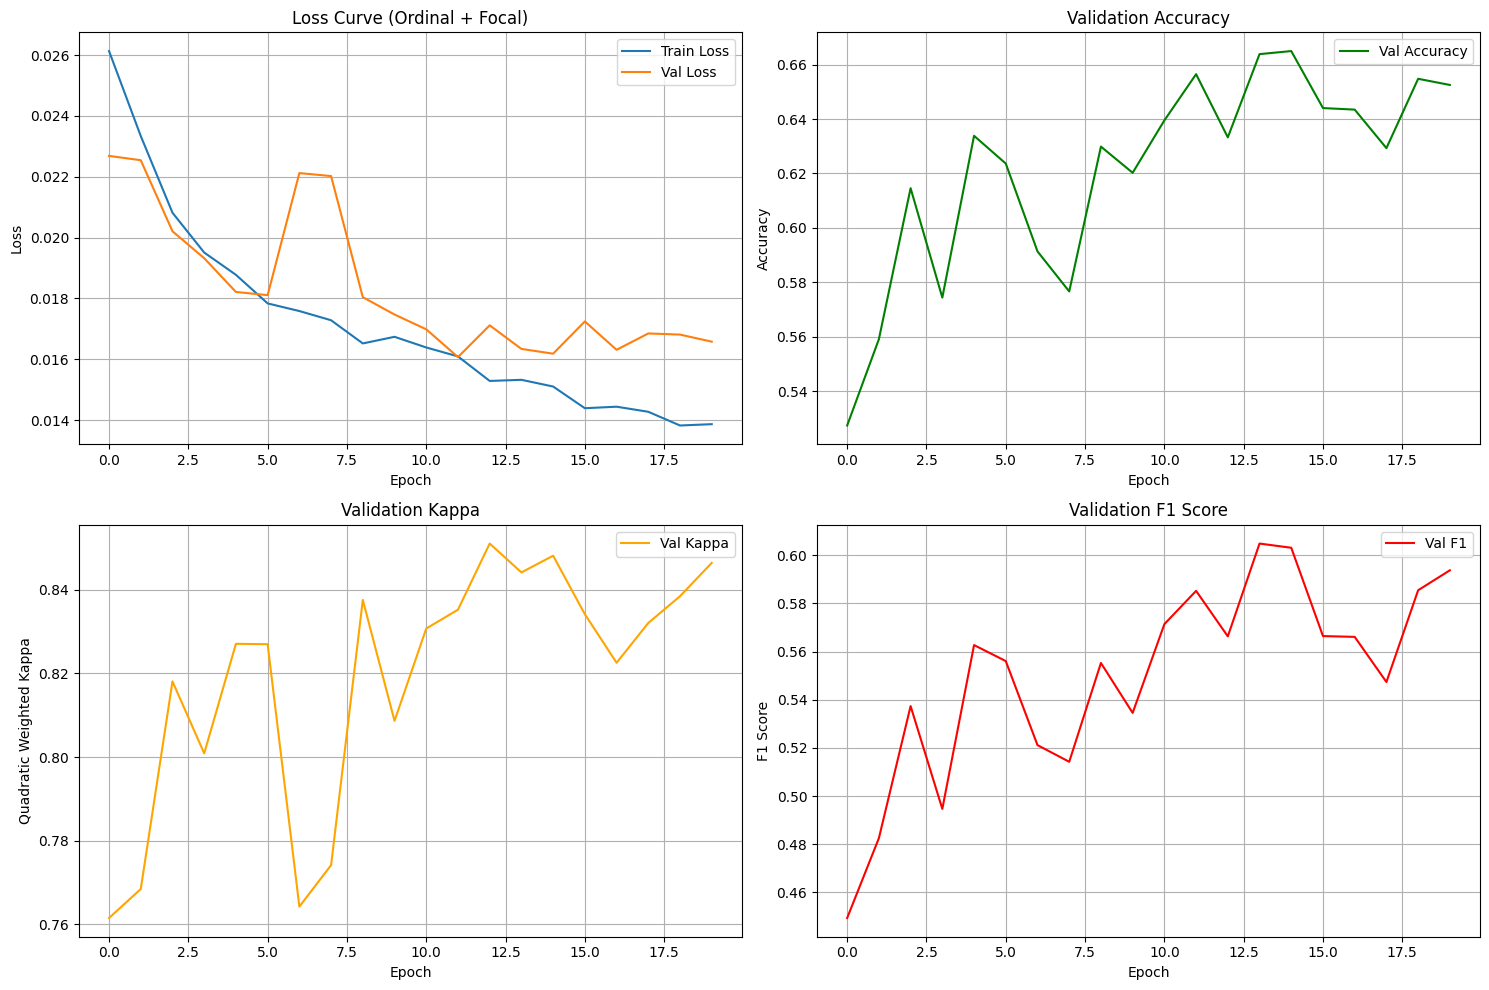

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss')
axes[0, 0].plot(history['val_loss'], label='Val Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curve (Ordinal + Focal)')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy
axes[0, 1].plot(history['val_acc'], label='Val Accuracy', color='green')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Kappa
axes[1, 0].plot(history['val_kappa'], label='Val Kappa', color='orange')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Quadratic Weighted Kappa')
axes[1, 0].set_title('Validation Kappa')
axes[1, 0].legend()
axes[1, 0].grid(True)

# F1 Score
axes[1, 1].plot(history['val_f1'], label='Val F1', color='red')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].set_title('Validation F1 Score')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-focal-training-attention.png', dpi=300, bbox_inches='tight')
plt.show()

## Evaluation on Test Set

Evaluating on test set...



Testing: 100%|██████████| 795/795 [01:19<00:00,  9.94it/s]



TEST SET RESULTS (Ordinal + Focal Loss)
Accuracy: 63.02%
Quadratic Weighted Kappa: 0.8442
Macro F1 Score: 0.5673

Classification Report:
              precision    recall  f1-score   support

      ISUP 0     0.7980    0.9101    0.8504       434
      ISUP 1     0.7645    0.6250    0.6878       400
      ISUP 2     0.4438    0.3750    0.4065       200
      ISUP 3     0.3544    0.3027    0.3265       185
      ISUP 4     0.4061    0.5668    0.4732       187
      ISUP 5     0.6667    0.6522    0.6593       184

    accuracy                         0.6302      1590
   macro avg     0.5723    0.5720    0.5673      1590
weighted avg     0.6321    0.6302    0.6262      1590


Confusion Matrix:
[[395  22   2   5   9   1]
 [ 68 250  68  11   3   0]
 [  7  39  75  61  15   3]
 [  8   6  17  56  85  13]
 [ 11   7   5  15 106  43]
 [  6   3   2  10  43 120]]


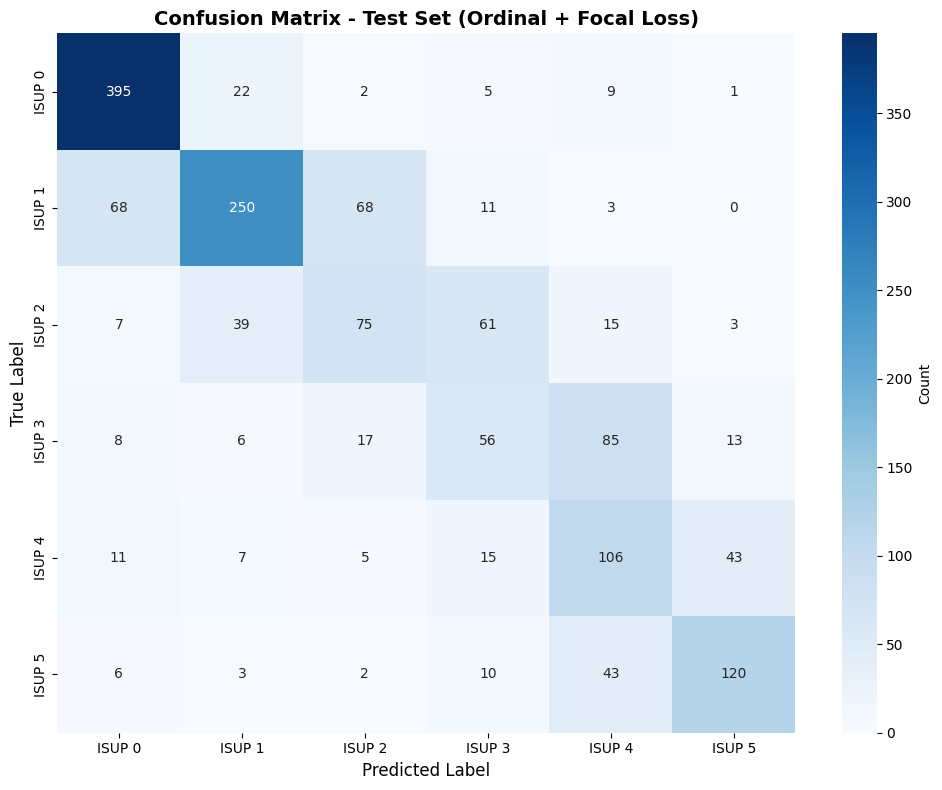


Test results saved to logs/b0-entropy-ordinal-focal-test-results.txt


In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load best model
model.load_state_dict(torch.load(model_path, weights_only=True))
model.eval()

# Evaluate on test set
test_preds = []
test_targets = []

print("Evaluating on test set...\n")

with torch.no_grad():
    for batch_data, batch_targets, _ in tqdm(test_loader, desc="Testing"):
        batch_data = batch_data.to(device)
        
        # Forward pass
        logits = model(batch_data)
        
        # Decode predictions
        predictions = decode_ordinal_predictions(logits)
        
        # Convert ordinal targets to class labels
        targets_class = batch_targets.sum(dim=1).long()
        
        test_preds.append(predictions.cpu())
        test_targets.append(targets_class)

# Concatenate results
test_preds = torch.cat(test_preds).numpy()
test_targets = torch.cat(test_targets).numpy()

# Calculate metrics
test_accuracy = accuracy_score(test_targets, test_preds)
test_kappa = cohen_kappa_score(test_targets, test_preds, weights='quadratic')
test_f1 = f1_score(test_targets, test_preds, average='macro', zero_division=0)

print("\n" + "="*80)
print("TEST SET RESULTS (Ordinal + Focal Loss)")
print("="*80)
print(f"Accuracy: {test_accuracy*100:.2f}%")
print(f"Quadratic Weighted Kappa: {test_kappa:.4f}")
print(f"Macro F1 Score: {test_f1:.4f}")
print("="*80)

# Classification report
print("\nClassification Report:")
print(classification_report(test_targets, test_preds, target_names=[f'ISUP {i}' for i in range(6)], digits=4, zero_division=0))

# Confusion matrix
cm = confusion_matrix(test_targets, test_preds)
print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[f'ISUP {i}' for i in range(6)],
    yticklabels=[f'ISUP {i}' for i in range(6)],
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - Test Set (Ordinal + Focal Loss)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-focal-attention-confusion-matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Save test results
with open('../logs/b0-entropy-ordinal-focal-attention-test-results.txt', 'w') as f:
    f.write("EfficientNet-B0 with Entropy Filtering, Ordinal Loss, and Focal Loss\n")
    f.write("="*80 + "\n\n")
    f.write(f"Test Accuracy: {test_accuracy*100:.2f}%\n")
    f.write(f"Test Quadratic Weighted Kappa: {test_kappa:.4f}\n")
    f.write(f"Test Macro F1 Score: {test_f1:.4f}\n\n")
    f.write("Classification Report:\n")
    f.write(classification_report(test_targets, test_preds, target_names=[f'ISUP {i}' for i in range(6)], digits=4, zero_division=0))
    f.write("\nConfusion Matrix:\n")
    f.write(str(cm))

print("\nTest results saved to logs/b0-entropy-ordinal-focal-test-results.txt")

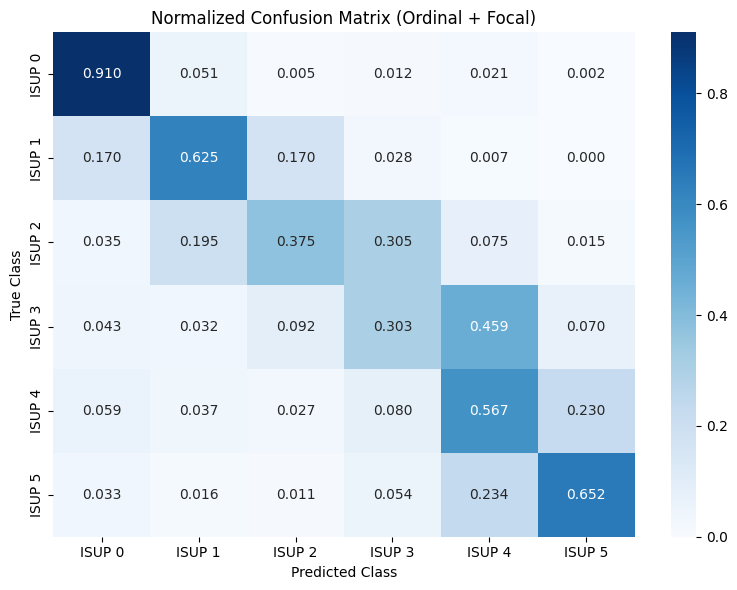

In [13]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Labels for classes
classes = ['ISUP 0', 'ISUP 1', 'ISUP 2', 'ISUP 3', 'ISUP 4', 'ISUP 5']

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)
plt.title("Normalized Confusion Matrix (Ordinal + Focal)")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-focal-attention-confusion-matrix-normalized.png', dpi=300, bbox_inches='tight')
plt.show()

Evaluating on test set...



Testing: 100%|██████████| 795/795 [01:19<00:00, 10.02it/s]


Running bootstrap resampling...


Bootstrap: 100%|██████████| 1000/1000 [00:01<00:00, 592.52it/s]



TEST SET RESULTS (Ordinal + Focal Loss + ATTENTION)
Accuracy :  63.02%  ±  1.21%  [95% CI: 60.75% – 65.35%]
QW Kappa :  0.8442  ±  0.0120  [95% CI: 0.8198 – 0.8665]
Macro F1 :  0.5673  ±  0.0122  [95% CI: 0.5429 – 0.5904]

Classification Report:
              precision    recall  f1-score   support

      ISUP 0     0.7980    0.9101    0.8504       434
      ISUP 1     0.7645    0.6250    0.6878       400
      ISUP 2     0.4438    0.3750    0.4065       200
      ISUP 3     0.3544    0.3027    0.3265       185
      ISUP 4     0.4061    0.5668    0.4732       187
      ISUP 5     0.6667    0.6522    0.6593       184

    accuracy                         0.6302      1590
   macro avg     0.5723    0.5720    0.5673      1590
weighted avg     0.6321    0.6302    0.6262      1590


Confusion Matrix:
[[395  22   2   5   9   1]
 [ 68 250  68  11   3   0]
 [  7  39  75  61  15   3]
 [  8   6  17  56  85  13]
 [ 11   7   5  15 106  43]
 [  6   3   2  10  43 120]]


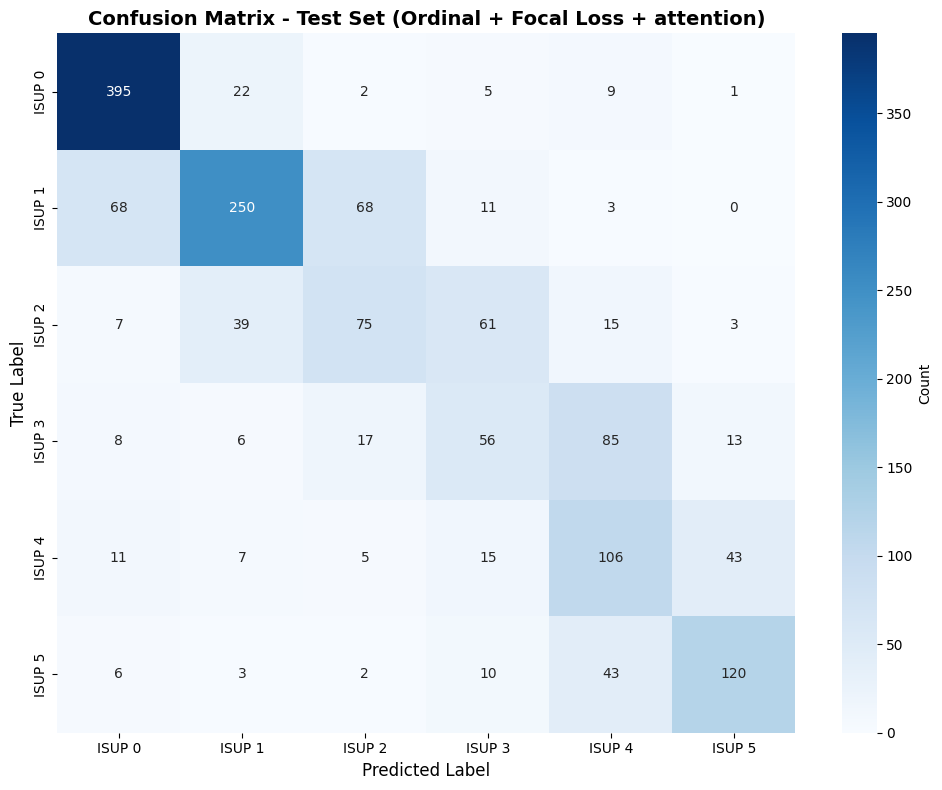


Test results saved to logs/b0-entropy-ordinal-focal-test-results.txt


In [14]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, cohen_kappa_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# Load best model
model.load_state_dict(torch.load(model_path, weights_only=True))
model.eval()

# Evaluate on test set
test_preds = []
test_targets = []

print("Evaluating on test set...\n")

with torch.no_grad():
    for batch_data, batch_targets, _ in tqdm(test_loader, desc="Testing"):
        batch_data = batch_data.to(device)

        logits = model(batch_data)
        predictions = decode_ordinal_predictions(logits)
        targets_class = batch_targets.sum(dim=1).long()

        test_preds.append(predictions.cpu())
        test_targets.append(targets_class)

test_preds = torch.cat(test_preds).numpy()
test_targets = torch.cat(test_targets).numpy()

# ── Point estimates ───────────────────────────────────────────────────────────
test_accuracy = accuracy_score(test_targets, test_preds)
test_kappa    = cohen_kappa_score(test_targets, test_preds, weights='quadratic')
test_f1       = f1_score(test_targets, test_preds, average='macro', zero_division=0)

# ── Bootstrap (1 000 resamples) ───────────────────────────────────────────────
N_BOOTSTRAP = 1000
rng = np.random.default_rng(seed=42)
n   = len(test_targets)

boot_acc    = np.empty(N_BOOTSTRAP)
boot_kappa  = np.empty(N_BOOTSTRAP)
boot_f1     = np.empty(N_BOOTSTRAP)

print("Running bootstrap resampling...")
for i in tqdm(range(N_BOOTSTRAP), desc="Bootstrap"):
    idx = rng.integers(0, n, size=n)          # resample with replacement
    y_true_b = test_targets[idx]
    y_pred_b = test_preds[idx]

    boot_acc[i]   = accuracy_score(y_true_b, y_pred_b)
    boot_kappa[i] = cohen_kappa_score(y_true_b, y_pred_b, weights='quadratic')
    boot_f1[i]    = f1_score(y_true_b, y_pred_b, average='macro', zero_division=0)

# ── Summary stats ─────────────────────────────────────────────────────────────
def boot_stats(arr, point_est):
    """Return (std, ci_lower, ci_upper) using the percentile method."""
    std     = arr.std(ddof=1)
    ci_low  = np.percentile(arr, 2.5)
    ci_high = np.percentile(arr, 97.5)
    return std, ci_low, ci_high

acc_std,   acc_ci_low,   acc_ci_high   = boot_stats(boot_acc,   test_accuracy)
kappa_std, kappa_ci_low, kappa_ci_high = boot_stats(boot_kappa, test_kappa)
f1_std,    f1_ci_low,    f1_ci_high    = boot_stats(boot_f1,    test_f1)

# ── Print results ─────────────────────────────────────────────────────────────
print("\n" + "="*80)
print("TEST SET RESULTS (Ordinal + Focal Loss + ATTENTION)")
print("="*80)
print(f"Accuracy :  {test_accuracy*100:.2f}%  ±  {acc_std*100:.2f}%  "
      f"[95% CI: {acc_ci_low*100:.2f}% – {acc_ci_high*100:.2f}%]")
print(f"QW Kappa :  {test_kappa:.4f}  ±  {kappa_std:.4f}  "
      f"[95% CI: {kappa_ci_low:.4f} – {kappa_ci_high:.4f}]")
print(f"Macro F1 :  {test_f1:.4f}  ±  {f1_std:.4f}  "
      f"[95% CI: {f1_ci_low:.4f} – {f1_ci_high:.4f}]")
print("="*80)

print("\nClassification Report:")
print(classification_report(test_targets, test_preds,
      target_names=[f'ISUP {i}' for i in range(6)], digits=4, zero_division=0))

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(test_targets, test_preds)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=[f'ISUP {i}' for i in range(6)],
    yticklabels=[f'ISUP {i}' for i in range(6)],
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - Test Set (Ordinal + Focal Loss + attention)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-focal-confusion-matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Save results ──────────────────────────────────────────────────────────────
with open('logs/b0-entropy-ordinal-focal-attention-test-results.txt', 'w') as f:
    f.write("EfficientNet-B0 with Entropy Filtering, Ordinal Loss, and Focal Loss\n")
    f.write("="*80 + "\n\n")
    f.write(f"Bootstrap resamples : {N_BOOTSTRAP}\n\n")
    f.write(f"Accuracy  : {test_accuracy*100:.2f}% ± {acc_std*100:.2f}%  "
            f"[95% CI: {acc_ci_low*100:.2f}% – {acc_ci_high*100:.2f}%]\n")
    f.write(f"QW Kappa  : {test_kappa:.4f} ± {kappa_std:.4f}  "
            f"[95% CI: {kappa_ci_low:.4f} – {kappa_ci_high:.4f}]\n")
    f.write(f"Macro F1  : {test_f1:.4f} ± {f1_std:.4f}  "
            f"[95% CI: {f1_ci_low:.4f} – {f1_ci_high:.4f}]\n\n")
    f.write("Classification Report:\n")
    f.write(classification_report(test_targets, test_preds,
            target_names=[f'ISUP {i}' for i in range(6)], digits=4, zero_division=0))
    f.write("\nConfusion Matrix:\n")
    f.write(str(cm))

print("\nTest results saved to logs/b0-entropy-ordinal-focal-test-results.txt")